In [1]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Đang sử dụng GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
# ----- Cấu hình -----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0004
epochs = 300

In [4]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [ ]:
# ----- Mạng Generator -----
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 28*28),
            nn.Tanh()  # output lung range [-1,1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), 1, 28, 28)
        return img

# ----- Mạng Discriminator -----
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()  # output xác suất
        )

    def forward(self, img):
        return self.model(img)

In [ ]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

In [11]:
# Storage for metrics
history = {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}

In [12]:
t0 = time.perf_counter()  # High-resolution timer
for epoch in range(1, epochs + 1):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)
        valid = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # -- Discriminator
        optimizer_D.zero_grad()
        loss_real = criterion(discriminator(real_imgs), valid)
        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)
        loss_fake = criterion(discriminator(gen_imgs.detach()), fake)
        loss_D = (loss_real + loss_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # -- Generator
        optimizer_G.zero_grad()
        loss_G = criterion(discriminator(gen_imgs), valid)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    avg_loss_D = epoch_loss_D / len(train_loader)
    avg_loss_G = epoch_loss_G / len(train_loader)
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_D'].append(avg_loss_D)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    print(f"[Epoch {epoch}/{epochs}] Loss_D: {avg_loss_D:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")

    if epoch % 20 == 0 or epoch == 1:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            test_imgs = generator(test_z).cpu()
            fig, axes = plt.subplots(4, 4, figsize=(4, 4))
            for img, ax in zip(test_imgs, axes.flatten()):
                ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.show()

ValueError: Using a target size (torch.Size([256, 1])) that is different to the input size (torch.Size([30976])) is deprecated. Please ensure they have the same size.

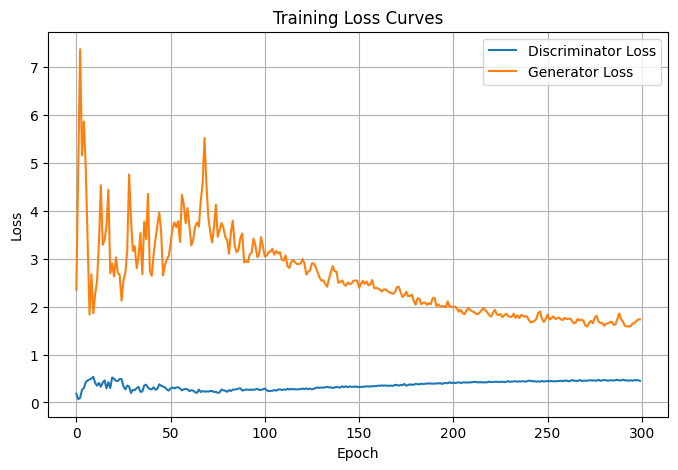

In [126]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_D'], label='Discriminator Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

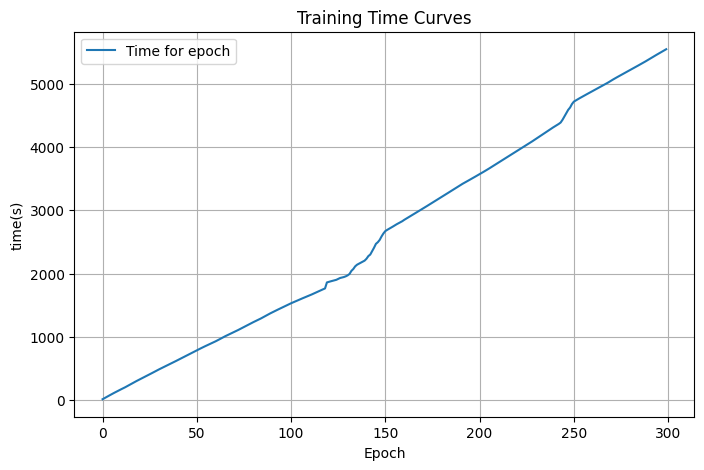

In [130]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [ ]:
# Export to CSV
csv_file = 'DCGAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_D', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_D'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_D': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

Training history exported to GAN_training_history.csv
